In [82]:
import os
import struct
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from agcounts_filter import convert_AC
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from scipy.signal import medfilt, resample_poly
from scipy.ndimage import maximum_filter1d

In [83]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/X_et_Y" 
folder = os.listdir(folder_path)

#////////////////////////////// Attention : le fichier LW est défini comme le dominant ////////////////////////////////

# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []

# Annotations all
Y_dom_all = []
Y_non_dom_all = []
# Annotations FAGA
Y_dom_faga = []
Y_non_dom_faga = []
# Annotations GA
Y_dom_ga = []
Y_non_dom_ga = []

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []

#Parcourir les fichiers CSV
for file in folder[52:56]: # //////////////////////// Ajuster les indices pour choisir le fichier à analyser
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":
        # Récupération des noms des colonnes pour pouvoir lire le fichier (pas le m^me pour tous)
        csv_file_column = pd.read_csv(folder_path + "/" + file, skiprows=5, sep = ',', low_memory = False)
        lst_column = list(csv_file_column)

        # Les fichiers n'ont pas tous le même nombre de données
        if lst_column == ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"]:
            data_file = pd.read_csv(folder_path + "/" + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"], dtype = {"Event":str},low_memory=False)
        elif lst_column == ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Quat W', 'Quat X', 'Quat Y', 'Quat Z', 'Unnamed: 11']:
            data_file = pd.read_csv(folder_path + "/" + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Quat W","Quat X","Quat Y","Quat Z"],low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-6:-4] == "RW":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-6:-4] == "LW":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

        

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de X ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                start_dom = int(round(float(my_sheet.cell(label.row,13).value))) + 1
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                start_non_dom = int(round(float(my_sheet.cell(label.row,13).value))) + 1
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True
            """allow_start_dom = True
            allow_start_non_dom = True"""
            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0, difference):
                        Y_dom.append(None) 
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    # GA
                    if label.value[-5:] == " V GA":
                        Y_dom_ga.append("mouvement")
                    elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                        Y_dom_ga.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom_ga.append(None)

                    # FAGA
                    if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                        Y_dom_faga.append("mouvement")
                    elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                        Y_dom_faga.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom_faga.append(None)


                    # all
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[-2:] == "GA" or label.value[-2:] == "FA": # GA : # if label.value[-5:] == " V GA": # FAGA : # if label.value[-5:] == " V GA" or label.value[-5:] == " V FA": # ALL : # if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_dom.append("mouvement")
                        Y_dom_all.append("mouvement")
                    elif label.value[3:13] == "sédentaire": # GA : # elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA": # FAGA # elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA": # ALL : #  elif label.value[3:13] == "sédentaire":
                        Y_dom.append("non mouvement")
                        Y_dom_all.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom.append(None) 
                        Y_dom_all.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    print(my_sheet.cell(row, 12).value)
                    print(type(my_sheet.cell(row, 12).value))
                    print(my_sheet.cell(previous_row_non_dom , 13).value)
                    print(type(my_sheet.cell(previous_row_non_dom , 13).value))
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None)

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    # GA 
                    if label.value[-5:] == " V GA":
                        Y_non_dom_ga.append("mouvement")
                    elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                        Y_non_dom_ga.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom_ga.append(None)
                    # FAGA
                    if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                        Y_non_dom_faga.append("mouvement")
                    elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                        Y_non_dom_faga.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom_faga.append(None)

                    # all    
                    if label.value[-2:] == "GA" or label.value[-2:] == "FA": # GA : # if label.value[-5:] == " V GA": # FAGA : # if label.value[-5:] == " V GA" or label.value[-5:] == " V FA": # ALL : # if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_non_dom.append("mouvement")
                        Y_non_dom_all.append("mouvement")
                    elif label.value[3:13] == "sédentaire": # GA : # elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA": # FAGA # elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA": # ALL : #  elif label.value[3:13] == "sédentaire"
                        Y_non_dom.append("non mouvement")
                        Y_non_dom_all.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)
                        Y_non_dom_all.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row

        """# CROPER X A LA LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)] 
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom) ]
        Y_non_dom = Y_non_dom[:len(X_non_dom) ]

        # cROPER LES ANNOTATIONS
        Y_dom_all = Y_dom_all[:len(X_dom)]
        Y_non_dom_all = Y_non_dom_all[:len(X_non_dom)]
        Y_dom_faga = Y_dom_faga[:len(X_dom)]
        Y_non_dom_faga = Y_non_dom_faga[:len(X_non_dom)]
        Y_dom_ga = Y_dom_ga[:len(X_dom)]
        Y_non_dom_ga = Y_non_dom_ga[:len(X_non_dom)]"""
        # Découpage de toutes les listes à la même longueur
        min_longueur = min(len(X_dom), len(X_non_dom), len(Y_dom_all), len(Y_non_dom_all))
        X_dom = X_dom[:min_longueur]
        X_non_dom = X_non_dom[:min_longueur]
        Y_dom_all = Y_dom_all[:min_longueur]
        Y_non_dom_all = Y_non_dom_all[:min_longueur]
        Y_dom_faga = Y_dom_faga[:min_longueur]
        Y_non_dom_faga = Y_non_dom_faga[:min_longueur]
        Y_dom_ga = Y_dom_ga[:min_longueur]
        Y_non_dom_ga = Y_non_dom_ga[:min_longueur]

Y_dom = np.array(Y_dom)
Y_non_dom = np.array(Y_non_dom)
X_dom = np.array(X_dom)
X_non_dom = np.array(X_non_dom)

On est dans le fichier : Data_214_LW.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_214_RW.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_214_TH.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_214_X.xlsx
47.207
<class 'str'>
36.453
<class 'str'>
524.835
<class 'str'>
523.496
<class 'str'>


In [84]:
print(X_dom)
print(Y_dom_all)

[ 0.          0.          8.         ... 74.51845409 31.06444913
  0.        ]
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', None, None, None, None, None, None, None, None, None, 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'mouvement', 'mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement'

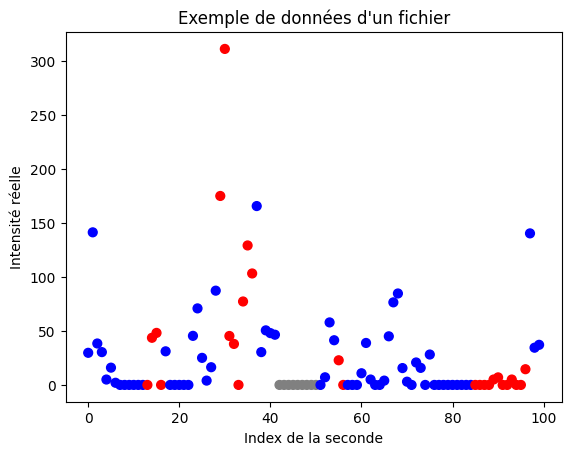

len(Y_non_dom) avant nettoyage : 1674


In [85]:
# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_non_dom_all[8:108]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(X_non_dom[8:108])), X_non_dom[8:108], c=colors, s=40)
plt.title("Exemple de données d'un fichier")
plt.xlabel("Index de la seconde")
plt.ylabel("Intensité réelle")
plt.show()

print("len(Y_non_dom) avant nettoyage :", len(Y_non_dom))

In [86]:
lst_X_members = [X_dom, X_non_dom]

lst_Y_pred = []
lst_Y_pred_2s = []

for idx_members in range(2):
    # On a X_dom et Y_dom : construire un Y_pred et le comparer à Y_dom
    Y_pred_0 = []
    Y_pred_2s = []
    for idx_data in range(0,len(lst_X_members[idx_members])-2, 2):
        window = np.mean(lst_X_members[idx_members][idx_data : idx_data + 2])
        if window > 0:
            Y_pred_0[len(Y_pred_0):] = [1,1] 
        elif window <= 0 :
           Y_pred_0[len(Y_pred_0):] = [0,0] 
        else:
            Y_pred_0.append(None)
    
    # Seuillage : mouvement si 2AC > 2
    for idx_data in range(0,len(lst_X_members[idx_members])-2, 2):
        window = np.mean(lst_X_members[idx_members][idx_data : idx_data + 2])
        if window > 2:
            Y_pred_2s[len(Y_pred_2s):] = [1,1]  
        elif window <= 2 :
           Y_pred_2s[len(Y_pred_2s):] = [0,0] 
        else:
            Y_pred_2s.append(None)
    
        
    lst_Y_pred.append(Y_pred_0)
    lst_Y_pred_2s.append(Y_pred_2s)


In [87]:
Y_dom_all = np.array(Y_dom_all)
Y_non_dom_all = np.array(Y_non_dom_all)
total_list_dom_sec = np.arange(1,len(Y_dom_all)+1)
total_list_non_dom_sec = np.arange(1,len(Y_non_dom_all)+1)
lst_Y_pred[0] = np.array(lst_Y_pred[0])
lst_Y_pred[1] = np.array(lst_Y_pred[1])
lst_Y_pred_2s[0] = np.array(lst_Y_pred_2s[0])
lst_Y_pred_2s[1] = np.array(lst_Y_pred_2s[1])

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_dom = Y_dom_all != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_non_dom = Y_non_dom_all != None

print("len mask non dom : ", len(mask_non_dom))
lst_Y_pred[0] = lst_Y_pred[0][mask_dom[:len(lst_Y_pred[0])]]
lst_Y_pred[1] = lst_Y_pred[1][mask_non_dom[:len(lst_Y_pred[1])]]
lst_Y_pred_2s[0] = lst_Y_pred_2s[0][mask_dom[:len(lst_Y_pred_2s[0])]]
lst_Y_pred_2s[1] = lst_Y_pred_2s[1][mask_non_dom[:len(lst_Y_pred_2s[1])]]

Y_dom_all = Y_dom_all[mask_dom]
Y_non_dom_all = Y_non_dom_all[mask_non_dom]
X_dom = X_dom[mask_dom]
X_non_dom = X_non_dom[mask_non_dom]
list_dom_sec =  total_list_dom_sec[mask_dom]
list_non_dom_sec = total_list_non_dom_sec[mask_non_dom]

print("len(Y_non_dom) après nettoyage :", len(Y_non_dom_all))

len mask non dom :  1661
len(Y_non_dom) après nettoyage : 1274


In [88]:
Y_dom_faga = np.array(Y_dom_faga)
Y_non_dom_faga = np.array(Y_non_dom_faga)
Y_dom_ga = np.array(Y_dom_ga)
Y_non_dom_ga = np.array(Y_non_dom_ga)


# GA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_dom = Y_dom_ga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_non_dom = Y_non_dom_ga != None

Y_dom_ga = Y_dom_ga[mask_ga_dom]
Y_non_dom_ga = Y_non_dom_ga[mask_ga_non_dom]

#FAGA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_dom = Y_dom_faga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_non_dom = Y_non_dom_faga != None

Y_dom_faga = Y_dom_faga[mask_faga_dom]
Y_non_dom_faga = Y_non_dom_faga[mask_faga_non_dom]


In [89]:
Y_dom_all = np.array(Y_dom_all)
Y_non_dom_all = np.array(Y_non_dom_all)
Y_dom_faga = np.array(Y_dom_faga)
Y_non_dom_faga = np.array(Y_non_dom_faga)
Y_dom_ga = np.array(Y_dom_ga)
Y_non_dom_ga = np.array(Y_non_dom_ga)

# -------------------------------------------- Transformation des labels --------------------------------------------
# Transformation des labels GA
Y_dom_ga_int = np.where(Y_dom_ga == 'mouvement' , 1, 0)
Y_non_dom_ga_int = np.where(Y_non_dom_ga == "mouvement", 1, 0)

# Transformation des labels GA
Y_dom_faga_int = np.where(Y_dom_faga == "mouvement" , 1, 0)
Y_non_dom_faga_int = np.where(Y_non_dom_faga == "mouvement", 1, 0)

# Transformation des labels all
Y_dom_all_int = np.where(Y_dom_all == "mouvement" , 1, 0)
Y_non_dom_all_int = np.where(Y_non_dom_all == "mouvement", 1, 0)

# ---------------------------- lst_Y_pred sont des numpy int mais Y_dom_all sont des int : il faut convertir les numpy int pour qu'ils correspondent aux int ------------------------------
# ga
Y_dom_ga_int = np.array(Y_dom_ga_int, dtype=np.int32)
Y_non_dom_ga_int = np.array(Y_non_dom_ga_int, dtype=np.int32)

# all
Y_dom_faga_int = np.array(Y_dom_faga_int, dtype=np.int32)
Y_non_dom_faga_int = np.array(Y_non_dom_faga_int, dtype=np.int32)

# all
Y_dom_all_int = np.array(Y_dom_all_int, dtype=np.int32)
Y_non_dom_all_int = np.array(Y_non_dom_all_int, dtype=np.int32)

# -------------------------------------------- Accuracy ---------------------------------------------

# ga
accuracy_dom_ga_0 = accuracy_score(Y_dom_ga_int[:len(lst_Y_pred[0])],lst_Y_pred[0])
print("Accuracy dom ga : ", accuracy_dom_ga_0)
accuracy_non_dom_ga_0 = accuracy_score(Y_non_dom_ga_int[:len(lst_Y_pred[1])],lst_Y_pred[1])
print("Accuracy non dom ga : ", accuracy_non_dom_ga_0)
accuracy_dom_ga_2s = accuracy_score(Y_dom_ga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0])
print("Accuracy dom ga : ", accuracy_dom_ga_2s)
accuracy_non_dom_ga_2s = accuracy_score(Y_non_dom_ga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1])
print("Accuracy non dom ga : ", accuracy_non_dom_ga_2s)

# faga
accuracy_dom_faga_0 = accuracy_score(Y_dom_faga_int[:len(lst_Y_pred[0])],lst_Y_pred[0])
print("Accuracy dom faga : ", accuracy_dom_faga_0)
accuracy_non_dom_faga_0 = accuracy_score(Y_non_dom_faga_int[:len(lst_Y_pred[1])],lst_Y_pred[1])
print("Accuracy non dom faga : ", accuracy_non_dom_faga_0)
accuracy_dom_faga_2s = accuracy_score(Y_dom_faga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0])
print("Accuracy dom faga : ", accuracy_dom_faga_2s)
accuracy_non_dom_faga_2s = accuracy_score(Y_non_dom_faga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1])
print("Accuracy non dom faga : ", accuracy_non_dom_faga_2s)

# all
accuracy_dom_all_0 = accuracy_score(Y_dom_all_int[:len(lst_Y_pred[0])],lst_Y_pred[0])
print("Accuracy dom all : ", accuracy_dom_all_0)
accuracy_non_dom_all_0 = accuracy_score(Y_non_dom_all_int[:len(lst_Y_pred[1])],lst_Y_pred[1])
print("Accuracy non dom all : ", accuracy_non_dom_all_0)
accuracy_dom_all_2s = accuracy_score(Y_dom_all_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0])
print("Accuracy dom all : ", accuracy_dom_all_2s)
accuracy_non_dom_all_2s = accuracy_score(Y_non_dom_all_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1])
print("Accuracy non dom all : ", accuracy_non_dom_all_2s)


# -------------------------------------------- F1 scores  ---------------------------------------------
# ga 
# 2AC > 0
f1_mvt_dom_ga_0 = f1_score(Y_dom_ga_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_ga_0 = f1_score(Y_dom_ga_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_ga_0 = f1_score(Y_non_dom_ga_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_ga_0 = f1_score(Y_non_dom_ga_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 0 , average = "binary")
# 2AC > 2
f1_mvt_dom_ga_2s = f1_score(Y_dom_ga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_ga_2s = f1_score(Y_dom_ga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_ga_2s = f1_score(Y_non_dom_ga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_ga_2s = f1_score(Y_non_dom_ga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 0 , average = "binary")

# faga
# 2AC > 0
f1_mvt_dom_faga_0 = f1_score(Y_dom_faga_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_faga_0 = f1_score(Y_dom_faga_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_faga_0 = f1_score(Y_non_dom_faga_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_faga_0 = f1_score(Y_non_dom_faga_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 0 , average = "binary")
# 2AC > 2
f1_mvt_dom_faga_2s = f1_score(Y_dom_faga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_faga_2s = f1_score(Y_dom_faga_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_faga_2s = f1_score(Y_non_dom_faga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_faga_2s = f1_score(Y_non_dom_faga_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 0 , average = "binary")

# all
# 2AC > 0
f1_mvt_dom_all_0 = f1_score(Y_dom_all_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_all_0 = f1_score(Y_dom_all_int[:len(lst_Y_pred[0])],lst_Y_pred[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_all_0 = f1_score(Y_non_dom_all_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_all_0 = f1_score(Y_non_dom_all_int[:len(lst_Y_pred[1])],lst_Y_pred[1], labels = [0,1], pos_label = 0 , average = "binary")
# 2AC > 2
f1_mvt_dom_all_2s = f1_score(Y_dom_all_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_all_2s = f1_score(Y_dom_all_int[:len(lst_Y_pred_2s[0])],lst_Y_pred_2s[0], labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_all_2s = f1_score(Y_non_dom_all_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_all_2s = f1_score(Y_non_dom_all_int[:len(lst_Y_pred_2s[1])],lst_Y_pred_2s[1], labels = [0,1], pos_label = 0 , average = "binary")




Accuracy dom ga :  0.578688524590164
Accuracy non dom ga :  0.5035349567949725
Accuracy dom ga :  0.5745901639344262
Accuracy non dom ga :  0.5051060487038491
Accuracy dom faga :  0.5926229508196721
Accuracy non dom faga :  0.5396700706991359
Accuracy dom faga :  0.5852459016393443
Accuracy non dom faga :  0.5412411626080126
Accuracy dom all :  0.5942622950819673
Accuracy non dom all :  0.5553809897879026
Accuracy dom all :  0.5836065573770491
Accuracy non dom all :  0.5569520816967792
